# Data Sources & Strategy

## Why This Pipeline Exists

**RavenPack** is the gold standard for firm-level financial news data:
every headline is pre-tagged with entity identifiers, relevance scores,
sentiment, and topic classifications. But its **terms of use prohibit
uploading headline text to LLMs** like ChatGPT for NLP analysis.

**The workaround:** source headlines independently from free sources,
then **fuzzy-match** them to RavenPack to inherit its entity metadata.
Only the independently-sourced headlines get uploaded to LLMs —
RavenPack's text stays local, but its metadata travels via the
crosswalk.

**Three headline sources in this pipeline:**

1. **RavenPack** — the metadata reference. High-quality entity tags and
   sentiment, but headlines cannot be uploaded to LLMs.
2. **GDELT** — free, massive, but noisy. Covers the open web, not wire
   services. Only ~7% of its headlines match RavenPack per-headline,
   but its enormous volume makes it the **largest contributor to overall
   RavenPack coverage**.
3. **Scraped newswires** (PR Newswire, Business Wire, GlobeNewswire) —
   higher per-headline match rates (same wire services RavenPack draws
   from), but smaller total volume limits their coverage contribution.

Both GDELT and newswire crosswalks are combined to maximize RavenPack
coverage. The pipeline links each free headline to its best RavenPack
match, transferring entity IDs and sentiment without violating terms
of use.

In [1]:
import re
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import polars as pl
from settings import config

DATA_DIR = Path(config("DATA_DIR"))

---
## Key Result: RavenPack Headline Coverage

In [2]:
_cw = pl.read_parquet(DATA_DIR / "newswire_ravenpack_crosswalk.parquet")

from pull_free_newswires import load_newswire_headlines as _load_nw

_nw_total_urls = (
    _load_nw()
    .with_columns(pl.col("date").cast(pl.Date))
    .filter(
        (pl.col("date") >= _cw["date"].min()) & (pl.col("date") <= _cw["date"].max())
    )
    .select(pl.col("source_url").n_unique())
    .collect()
    .item()
)
_nw_matched_urls = _cw["nw_source_url"].n_unique()
_nw_match_rate = _nw_matched_urls / _nw_total_urls * 100

_rp_full = (
    pl.scan_parquet(DATA_DIR / "ravenpack_djpr.parquet")
    .with_columns(pl.col("timestamp_utc").cast(pl.Date).alias("date"))
    .filter(
        (pl.col("date") >= _cw["date"].min()) & (pl.col("date") <= _cw["date"].max())
    )
    .select("rp_story_id")
)
_rp_total_stories = _rp_full.select(pl.col("rp_story_id").n_unique()).collect().item()
_rp_matched_stories = _cw["rp_story_id"].n_unique()
_rp_match_rate = _rp_matched_stories / _rp_total_stories * 100

pl.DataFrame({
    "metric": [
        "RP headlines matched",
        "NW headlines matched",
        "Crosswalk pairs",
        "Date range",
    ],
    "value": [
        f"{_rp_match_rate:.1f}% ({_rp_matched_stories:,} / {_rp_total_stories:,})",
        f"{_nw_match_rate:.1f}% ({_nw_matched_urls:,} / {_nw_total_urls:,})",
        f"{len(_cw):,}",
        f"{_cw['date'].min()} to {_cw['date'].max()} ({_cw['date'].n_unique():,} dates)",
    ],
})

/opt/homebrew/Caskroom/mambaforge/base/lib/python3.10/site-packages/google/api_core/_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.14) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


metric,value
str,str
"""RP headlines matched""","""2.9% (509,932 / 17,636,011)"""
"""NW headlines matched""","""22.5% (532,609 / 2,363,887)"""
"""Crosswalk pairs""","""533,265"""
"""Date range""","""2010-03-18 to 2026-02-28 (3,83…"


---
## 1. RavenPack — `ravenpack_djpr.parquet`

Source script: `pull_ravenpack.py`

One row per news article / entity event from the RavenPack Dow Jones Press
Release feed. Filtered for US companies (`country_code='US'`),
high relevance ($\geq 90$), and single-firm stories only.

RavenPack's strengths: curated entity matching, sentiment scores, and
topic classification. Its content is **~95% wire services** (Dow Jones,
PR Newswire, Business Wire, GlobeNewswire). The limitation: headline
text cannot be uploaded to LLMs under RavenPack's terms of use.

**Key columns:**

| Column | Description |
|---|---|
| `timestamp_utc` | Publication timestamp (UTC) |
| `rp_entity_id` | RavenPack entity identifier |
| `entity_name` | Company name |
| `headline` | Article headline text |
| `event_sentiment_score` | Sentiment score (−1 to +1) |
| `css` | Composite Sentiment Score (0–100) |
| `relevance` | Entity relevance to the article (0–100) |
| `topic` | RavenPack topic classification |
| `news_type` | News type (e.g. press-release, article) |
| `source_name` | Name of the news source |

In [3]:
rp = pl.scan_parquet(DATA_DIR / "ravenpack_djpr.parquet")
n_rows = rp.select(pl.len()).collect().item()
cols = rp.collect_schema().names()
print(f"Rows: {n_rows:,}  |  Columns: {len(cols)}")
print(f"Column names: {cols}")

Rows: 40,175,083  |  Columns: 25
Column names: ['timestamp_utc', 'rp_story_id', 'rp_entity_id', 'entity_type', 'entity_name', 'country_code', 'relevance', 'event_sentiment_score', 'event_relevance', 'event_similarity_key', 'event_similarity_days', 'topic', 'rp_group', 'rp_type', 'sub_type', 'property', 'fact_level', 'category', 'news_type', 'rp_source_id', 'source_name', 'provider_id', 'provider_story_id', 'headline', 'css']


### Example rows

In [4]:
rp.head(5).collect()

timestamp_utc,rp_story_id,rp_entity_id,entity_type,entity_name,country_code,relevance,event_sentiment_score,event_relevance,event_similarity_key,event_similarity_days,topic,rp_group,rp_type,sub_type,property,fact_level,category,news_type,rp_source_id,source_name,provider_id,provider_story_id,headline,css
datetime[ns],str,str,str,str,str,f64,f64,f64,str,f64,str,str,str,str,str,str,str,str,str,str,str,str,str,f64
2000-01-01 17:52:28,"""52D513EA9040443376A6B1747B0FA8…","""047E26""","""COMP""","""Sprint Corp.""","""US""",92.0,null,null,null,null,null,null,null,null,null,null,null,"""FULL-ARTICLE""","""B5569E""","""Dow Jones Newswires""","""DJ""","""DN20000101000112""","""Sprint Says No Y2K Rollover Pr…",-0.06
2000-01-04 16:20:09,"""EBA7EA21C1F4C4E3DAB00078A0158F…","""619882""","""COMP""","""JPMorgan Chase & Co.""","""US""",91.0,null,null,null,null,null,null,null,null,null,null,null,"""TABULAR-MATERIAL""","""B5569E""","""Dow Jones Newswires""","""DJ""","""DN20000104001275""","""Chase Manhattan (CMB) Block: 2…",0.0
2000-01-04 17:09:31,"""35BAA12B8E5A3EFF50C5D677F53101…","""619882""","""COMP""","""JPMorgan Chase & Co.""","""US""",90.0,null,null,null,null,null,null,null,null,null,null,null,"""NEWS-FLASH""","""B5569E""","""Dow Jones Newswires""","""DJ""","""DN20000104001590""","""Chase H&Q Starts MotherNature.…",0.06
2000-01-04 18:16:36,"""0AA17F1E569B8DEECBD24539957F89…","""619882""","""COMP""","""JPMorgan Chase & Co.""","""US""",92.0,null,null,null,null,null,null,null,null,null,null,null,"""TABULAR-MATERIAL""","""B5569E""","""Dow Jones Newswires""","""DJ""","""DN20000104001889""","""FHLB $200M 2-Yr Taps Via J.P. …",0.0
2000-01-04 19:14:26,"""97B979351D2EE5CF60063AA2F780ED…","""619882""","""COMP""","""JPMorgan Chase & Co.""","""US""",91.0,null,null,null,null,null,null,null,null,null,null,null,"""FULL-ARTICLE""","""B5569E""","""Dow Jones Newswires""","""DJ""","""DN20000104002192""","""J. P. Morgan Trade Weighted Ef…",0.0


### Date range

In [5]:
rp.select(
    pl.col("timestamp_utc").min().alias("earliest"),
    pl.col("timestamp_utc").max().alias("latest"),
).collect()

earliest,latest
datetime[ns],datetime[ns]
2000-01-01 00:24:51,2026-02-28 23:19:01.856


### Articles per month

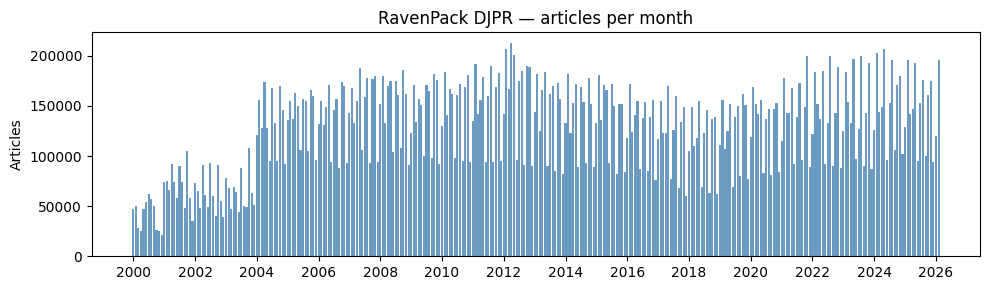

In [6]:
rp_monthly = (
    rp.with_columns(pl.col("timestamp_utc").cast(pl.Date).alias("date"))
    .group_by(pl.col("date").dt.truncate("1mo"))
    .agg(pl.len().alias("n_articles"))
    .sort("date")
    .collect()
)

fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(
    rp_monthly["date"].to_list(),
    rp_monthly["n_articles"].to_list(),
    width=25,
    color="steelblue",
    alpha=0.8,
)
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_ylabel("Articles")
ax.set_title("RavenPack DJPR — articles per month")
fig.tight_layout()
plt.show()

---
## 2. S&P 500 Constituents — `sp500_constituents.parquet`

Source script: `pull_sp500_constituents.py`

Historical membership list of the S&P 500 index from CRSP
(`crsp_m_indexes.dsp500list_v2`). Each row is one membership spell
for a single PERMNO — i.e. the period during which a stock was part
of the index.

**Key columns:**

| Column | Description |
|---|---|
| `permno` | CRSP permanent security identifier |
| `mbrstartdt` | Date the stock entered the S&P 500 (inclusive) |
| `mbrenddt` | Date the stock exited the S&P 500 (exclusive) |
| `indno` | Index identifier |
| `mbrflg` | Membership flag |

In [7]:
sp = pl.scan_parquet(DATA_DIR / "sp500_constituents.parquet")
n_rows_sp = sp.select(pl.len()).collect().item()
cols_sp = sp.collect_schema().names()
print(f"Rows: {n_rows_sp:,}  |  Columns: {len(cols_sp)}")
print(f"Column names: {cols_sp}")

Rows: 8,284  |  Columns: 13
Column names: ['permno', 'indno', 'mbrstartdt', 'mbrenddt', 'mbrflg', 'indfam', 'comnam', 'ticker', 'ncusip', 'namedt', 'nameenddt', 'siccd', 'exchcd']


### Example rows

In [8]:
sp.head(5).collect()

permno,indno,mbrstartdt,mbrenddt,mbrflg,indfam,comnam,ticker,ncusip,namedt,nameenddt,siccd,exchcd
i64,i64,datetime[ns],datetime[ns],str,i64,str,str,str,datetime[ns],datetime[ns],i64,i64
10006,1000500,1957-03-01 00:00:00,1984-07-18 00:00:00,"""NORM""",1100500,"""AMERICAN CAR & FDRY CO""",null,null,1925-12-31 00:00:00,1954-05-31 00:00:00,3740,1
10006,1000500,1957-03-01 00:00:00,1984-07-18 00:00:00,"""NORM""",1100500,"""A C F INDUSTRIES INC""",null,null,1954-06-01 00:00:00,1962-07-01 00:00:00,3740,1
10006,1000500,1957-03-01 00:00:00,1984-07-18 00:00:00,"""NORM""",1100500,"""A C F INDUSTRIES INC""","""ACF""",null,1962-07-02 00:00:00,1968-01-01 00:00:00,3743,1
10006,1000500,1957-03-01 00:00:00,1984-07-18 00:00:00,"""NORM""",1100500,"""A C F INDUSTRIES INC""","""ACF""","""00080010""",1968-01-02 00:00:00,1984-06-28 00:00:00,3743,1
10030,1000500,1957-03-01 00:00:00,1969-01-08 00:00:00,"""NORM""",1100500,"""AMERICAN BRAKE SHOE & FDRY""",null,null,1925-12-31 00:00:00,1943-04-26 00:00:00,3310,1


### Membership date range

In [9]:
sp.select(
    pl.col("mbrstartdt").min().alias("earliest_start"),
    pl.col("mbrstartdt").max().alias("latest_start"),
    pl.col("mbrenddt").min().alias("earliest_end"),
    pl.col("mbrenddt").max().alias("latest_end"),
).collect()

earliest_start,latest_start,earliest_end,latest_end
datetime[ns],datetime[ns],datetime[ns],datetime[ns]
1925-12-31 00:00:00,2026-02-09 00:00:00,1928-08-24 00:00:00,2026-02-27 00:00:00


### Unique constituents over full history

In [10]:
n_unique = sp.select(pl.col("permno").n_unique()).collect().item()
print(f"Distinct PERMNOs that have ever been in the S&P 500: {n_unique:,}")

Distinct PERMNOs that have ever been in the S&P 500: 1,956


---
## 3. GDELT S&P 500 — `gdelt_sp500_headlines/`

Source script: `pull_gdelt_sp500_headlines.py`

Page-title headlines extracted from GDELT's Global Knowledge Graph 2.0,
filtered server-side in BigQuery to articles mentioning S&P 500 companies.
Stored as a Hive-partitioned data lake (`year=YYYY/month=MM/data.parquet`).

GDELT is **free and massive** (~400k articles/day), but its content comes
from the **open web** — blogs, aggregators, regional news — not the wire
services that dominate RavenPack. This means fuzzy-match overlap with
RavenPack is low (~7%). The false-positive problem and filtering quality
are explored in notebook 02. We will use GDELT in more depth in a
separate project.

**Key columns:**

| Column | Description |
|---|---|
| `gkg_date` | GKG record timestamp |
| `source_url` | Full URL of the source article |
| `source_name` | Domain / common name of the news source |
| `headline` | Page title extracted from `<PAGE_TITLE>` tags |
| `matched_company` | S&P 500 company name matched via V2Organizations |
| `permno` | CRSP permanent security identifier |
| `ticker` | Stock ticker symbol |

In [11]:
from pull_gdelt_sp500_headlines import (
    SAMPLE_MONTH,
    filter_to_month,
    load_gdelt_sp500_headlines,
)

gd = filter_to_month(load_gdelt_sp500_headlines(), SAMPLE_MONTH)
n_rows_gd = gd.select(pl.len()).collect().item()
cols_gd = gd.collect_schema().names()
print(f"Rows: {n_rows_gd:,}  |  Columns: {len(cols_gd)}")
print(f"Column names: {cols_gd}")

Rows: 447,910  |  Columns: 12
Column names: ['gkg_date', 'source_url', 'source_name', 'V2Tone', 'V2Organizations', 'matched_org_raw', 'matched_company', 'permno', 'ticker', 'headline', 'year', 'month']


### Example rows

In [12]:
gd.head(5).collect()

gkg_date,source_url,source_name,V2Tone,V2Organizations,matched_org_raw,matched_company,permno,ticker,headline,year,month
"datetime[μs, UTC]",str,str,str,str,str,str,i64,str,str,i64,i64
2025-01-27 18:15:00 UTC,"""https://marxist.com/trump-and-…","""marxist.com""","""-3.68271954674221,2.5091056252…","""Flickr,13421;United States,226…","""United States""","""UNITED STATES BANCORP""",78968,"""USBC""","""Trump and Starmer: America Fir…",2025,1
2025-01-28 02:15:00 UTC,"""https://abc7.com/post/police-r…","""abc7.com""","""-4.13533834586466,0.3759398496…","""Union Pacific,1130;Union Pacif…","""Union Pacific""","""UNION PACIFIC CORP""",48725,"""UNP""","""Police respond to mystery behi…",2025,1
2025-01-28 12:15:00 UTC,"""https://english.aawsat.com/tec…","""aawsat.com""","""0.126103404791929,4.5397225725…","""Nvidia,747;Nvidia,878;Nvidia,3…","""Microsoft""","""MICROSOFT CORP""",10107,"""MSFT""","""Trump Warns of 'Wake-up Call' …",2025,1
2025-01-06 13:00:00 UTC,"""https://finance.yahoo.com/rese…","""yahoo.com""","""0.894854586129754,2.2371364653…","""Albertsons,2364;National Day O…","""Albertsons""","""ALBERTSONS INC""",50032,"""ABS""","""Netflix, Inc. (NFLX) Stock For…",2025,1
2025-01-01 19:15:00 UTC,"""https://www.postandcourier.com…","""postandcourier.com""","""4.77941176470588,5.88235294117…","""Facebook,1557""","""Facebook""","""FACEBOOK INC""",13407,"""FB""","""American Pickers to film in So…",2025,1


### Date range

In [13]:
gd.select(
    pl.col("gkg_date").min().alias("earliest"),
    pl.col("gkg_date").max().alias("latest"),
).collect()

earliest,latest
"datetime[μs, UTC]","datetime[μs, UTC]"
2025-01-01 00:00:00 UTC,2025-01-31 23:45:00 UTC


### Headlines per day

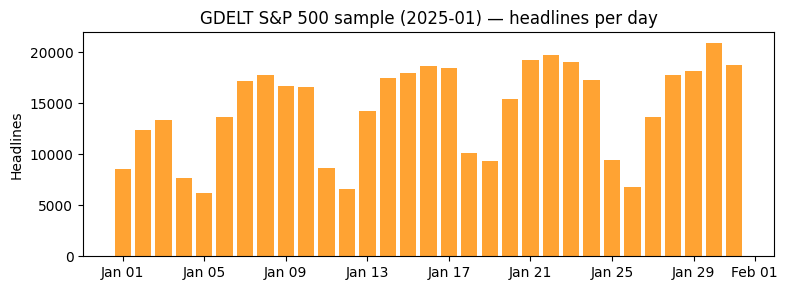

In [14]:
gd_collected = gd.collect()
gd_daily = (
    gd_collected.with_columns(pl.col("gkg_date").cast(pl.Date).alias("date"))
    .group_by("date")
    .agg(pl.len().alias("n_headlines"))
    .sort("date")
)

fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(
    gd_daily["date"].to_list(),
    gd_daily["n_headlines"].to_list(),
    color="darkorange",
    alpha=0.8,
)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.set_ylabel("Headlines")
ax.set_title(f"GDELT S&P 500 sample ({SAMPLE_MONTH}) — headlines per day")
fig.tight_layout()
plt.show()

---
## 4. Free Newswires — `newswire_headlines/`

Source script: `pull_free_newswires.py`

Press release headlines scraped from PR Newswire via sitemap crawling,
then filtered locally to S&P 500 companies using normalized company
name substring matching.

These are the **same wire services that RavenPack draws from**, scraped
directly from their public-facing websites. This makes scraped newswires
the **primary headline source** for matching to RavenPack — because
the underlying press releases are identical, fuzzy-match rates are much
higher than with GDELT.

**Key columns:**

| Column | Description |
|---|---|
| `date` | Publication date (YYYY-MM-DD) |
| `headline` | Press release headline text |
| `source_url` | Full URL of the press release |
| `source_name` | Wire service name (PR Newswire) |
| `matched_company` | S&P 500 company name matched via substring |
| `permno` | CRSP permanent security identifier |
| `ticker` | Stock ticker symbol |

In [15]:
from pull_free_newswires import load_newswire_headlines
from pull_sp500_constituents import load_sp500_names_lookup, normalize_company_name

raw = load_newswire_headlines().collect()

# Map Hive partition key to human-readable source name
if "source" in raw.columns and "source_name" not in raw.columns:
    source_map = {"prnewswire": "PR Newswire"}
    raw = raw.with_columns(
        pl.col("source")
        .replace_strict(source_map, default="Unknown")
        .alias("source_name")
    )

# Filter to S&P 500 companies via normalized name matching
lookup = pl.from_pandas(load_sp500_names_lookup())
names = sorted(
    [n for n in lookup["comnam_norm"].unique().to_list() if n], key=len, reverse=True
)
pattern = "(" + "|".join(re.escape(n) for n in names) + ")"

raw = raw.with_columns(
    pl.col("headline")
    .map_elements(normalize_company_name, return_dtype=pl.Utf8)
    .alias("headline_norm")
)
nw = raw.filter(pl.col("headline_norm").str.contains(pattern))
nw = nw.with_columns(
    pl.col("headline_norm").str.extract(pattern, group_index=1).alias("matched_norm")
)
lookup_dedup = lookup.select("comnam_norm", "comnam", "permno", "ticker").unique(
    subset=["comnam_norm"], keep="first"
)
nw = nw.join(
    lookup_dedup, left_on="matched_norm", right_on="comnam_norm", how="left"
).rename({"comnam": "matched_company"})
nw = nw.drop("headline_norm", "matched_norm").lazy()

n_rows_nw = nw.select(pl.len()).collect().item()
cols_nw = nw.collect_schema().names()
print(f"Rows: {n_rows_nw:,}  |  Columns: {len(cols_nw)}")
print(f"Column names: {cols_nw}")

Rows: 766,587  |  Columns: 11
Column names: ['headline', 'source_url', 'date', 'source', 'year', 'month', 'day', 'source_name', 'matched_company', 'permno', 'ticker']


### Example rows

In [16]:
nw.head(5).collect()

headline,source_url,date,source,year,month,day,source_name,matched_company,permno,ticker
str,str,str,str,i64,i64,i64,str,str,i64,str
"""Brookfield Property Partners C…","""https://www.globenewswire.com/…","""2026-02-27""","""globenewswire""",2026,2,27,"""Unknown""","""ROPER CORP""",20343,"""ROP"""
"""BBWI FINAL DEADLINE: ROSEN, A …","""https://www.globenewswire.com/…","""2026-02-27""","""globenewswire""",2026,2,27,"""Unknown""","""BATH & BODY WORKS INC""",64282,"""BBWI"""
"""ROSEN, A LEADING NATIONAL FIRM…","""https://www.globenewswire.com/…","""2026-02-27""","""globenewswire""",2026,2,27,"""Unknown""","""NATIONAL SYSTEMS CORP""",47028,"""NSY"""
"""NASDAQ: CVLT Investigation Ale…","""https://www.globenewswire.com/…","""2026-02-27""","""globenewswire""",2026,2,27,"""Unknown""","""NASDAQ INC""",90601,"""NDAQ"""
"""Sanford Heisler Sharp McKnight…","""https://www.globenewswire.com/…","""2026-02-27""","""globenewswire""",2026,2,27,"""Unknown""","""COMPASS BANCSHARES INC""",22032,"""CBSS"""


### Full headline examples

In [17]:
for h in nw.select("headline").head(8).collect()["headline"].to_list():
    print(f"  • {h}")

  • Brookfield Property Partners Completes 2025 Annual Filings
  • BBWI FINAL DEADLINE: ROSEN, A GLOBAL AND LEADING LAW FIRM, Encourages Bath & Body Works, Inc. Investors to Secure Counsel Before Important Deadline in Securities Class Action - BBWI
  • ROSEN, A LEADING NATIONAL FIRM, Encourages Franklin BSP Realty Trust, Inc. Investors to Secure Counsel Before Important Deadline in Securities Class Action – FBRT
  • NASDAQ: CVLT Investigation Alert: Kessler Topaz Meltzer & Check, LLP Encourages Commvault Systems, Inc. (NASDAQ: CVLT) Investors to Contact the Firm
  • Sanford Heisler Sharp McKnight Secures Compassionate Release for Richard Brown in 1988 Kansas City Fire Case
  • ROSEN, A TRUSTED AND LEADING LAW FIRM, Encourages Richtech Robotics Inc. Investors to Secure Counsel Before Important Deadline in Securities Class Action First Filed by the Firm – RR
  • J. August to Reopen in Harvard Square
  • Nordic Naturals and Kate Turner Discuss Why More Than 80% of Americans Are Falling Sh

---
## 5. Newswire–RavenPack Crosswalk — `newswire_ravenpack_crosswalk.parquet`

Source script: `create_newswire_ravenpack_crosswalk.py`

Fuzzy-matched bridge between free newswire headlines and RavenPack DJ Press
Release headlines. Each row is the single best RavenPack match for a given
newswire headline on the same calendar date, kept only when the
`token_sort_ratio` score is $\geq 80$.

**This is the key pipeline output.** It enables enriching free newswire data
with RavenPack's entity identifiers and sentiment scores, without uploading
RavenPack's headline text to any external service.

**Key columns:**

| Column | Description |
|---|---|
| `date` | Calendar date of the matched headlines |
| `nw_source_url` | URL of the newswire press release |
| `nw_headline` | Original headline from the newswire source |
| `nw_source` | Wire service identifier (e.g. `prnewswire`) |
| `rp_story_id` | RavenPack unique story identifier |
| `rp_entity_id` | RavenPack entity identifier |
| `rp_entity_name` | Company name as recorded by RavenPack |
| `rp_headline` | Headline text from RavenPack |
| `rp_source_name` | News source as classified by RavenPack |
| `fuzzy_score` | Token-sort-ratio similarity score (80–100) |

In [18]:
cw = pl.scan_parquet(DATA_DIR / "newswire_ravenpack_crosswalk.parquet")
n_rows_cw = cw.select(pl.len()).collect().item()
cols_cw = cw.collect_schema().names()
print(f"Rows: {n_rows_cw:,}  |  Columns: {len(cols_cw)}")
print(f"Column names: {cols_cw}")

Rows: 533,265  |  Columns: 10
Column names: ['date', 'nw_source_url', 'nw_headline', 'nw_source', 'rp_story_id', 'rp_entity_id', 'rp_entity_name', 'rp_headline', 'rp_source_name', 'fuzzy_score']


### Example rows

In [19]:
cw.head(5).collect()

date,nw_source_url,nw_headline,nw_source,rp_story_id,rp_entity_id,rp_entity_name,rp_headline,rp_source_name,fuzzy_score
date,str,str,str,str,str,str,str,str,f64
2010-03-18,"""https://www.prnewswire.com/new…","""Bankrate: Mortgage Rates Post …","""prnewswire""","""E64A213B99397C2294402E85A71280…","""977048""","""Bankrate Inc.""","""Bankrate: Mortgage Rates Post …","""PR Newswire""",100.0
2010-09-30,"""https://www.prnewswire.com/new…","""Miss Tina by Tina Knowles Avai…","""prnewswire""","""334F29AA0CB6DFBA98DF2E4E284839…","""713810""","""Wal-Mart Stores Inc.""","""Miss Tina by Tina Knowles Avai…","""PR Newswire""",100.0
2010-11-30,"""https://www.prnewswire.com/new…","""Knoll to Distribute Residentia…","""prnewswire""","""8832B211A6FA9888C74AB03871CE49…","""8D4AE6""","""Knoll Inc.""","""Knoll to Distribute Residentia…","""PR Newswire""",100.0
2010-12-01,"""https://www.prnewswire.com/new…","""Just In Time for Holiday Shopp…","""prnewswire""","""AB5515F66A3AC06D97CC1CA144E94E…","""385DD4""","""Marriott International Inc.""","""Just In Time for Holiday Shopp…","""PR Newswire""",100.0
2010-12-01,"""https://www.prnewswire.com/new…","""Weber Shandwick President Andy…","""prnewswire""","""7863A7BC99C352D63E49EA29B13AFB…","""E30B34""","""Interpublic Group Of Cos. Inc.""","""Weber Shandwick President Andy…","""PR Newswire""",100.0


### Date range

In [20]:
cw.select(
    pl.col("date").min().alias("earliest"),
    pl.col("date").max().alias("latest"),
).collect()

earliest,latest
date,date
2010-03-18,2026-02-28


### Fuzzy-score distribution

fuzzy_score — mean: 98.8,  median: 100.0,  min: 80.0,  max: 100.0


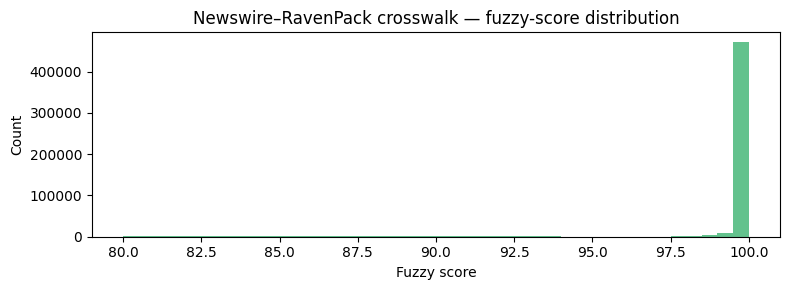

In [21]:
cw_collected = cw.collect()
print(
    f"fuzzy_score — mean: {cw_collected['fuzzy_score'].mean():.1f},  "
    f"median: {cw_collected['fuzzy_score'].median():.1f},  "
    f"min: {cw_collected['fuzzy_score'].min():.1f},  "
    f"max: {cw_collected['fuzzy_score'].max():.1f}"
)

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(cw_collected["fuzzy_score"].to_list(), bins=40, color="mediumseagreen", alpha=0.8)
ax.set_xlabel("Fuzzy score")
ax.set_ylabel("Count")
ax.set_title("Newswire–RavenPack crosswalk — fuzzy-score distribution")
fig.tight_layout()
plt.show()

---
## GDELT vs Scraped Newswires: Different Strengths

RavenPack's content is **~95% wire services** — Dow Jones Newswires,
PR Newswire, Business Wire, and GlobeNewswire. Scraping these wire
services directly gives us the **same underlying press releases** that
RavenPack processes, so the **per-headline match rate is high**.

GDELT crawls the **open web** — Yahoo Finance, aggregator sites,
regional news, blogs. Only **~7%** of GDELT's S&P 500 headlines match
RavenPack because they draw from fundamentally different source
ecosystems. However, GDELT's **sheer volume** (hundreds of thousands
of articles per day) compensates: despite the low per-headline match
rate, GDELT actually covers a **larger fraction of the RavenPack
universe** than newswire alone.

In short: **newswire matches are more precise; GDELT matches are more
numerous.** Both sources are needed for maximum RavenPack coverage.
See notebook 03 (Crosswalk Quality) for the per-source breakdown chart.

---
## Source Comparison

| | RavenPack | GDELT | Scraped Newswires |
|---|---|---|---|
| **Cost** | Commercial | Free (BQ scan costs) | Free |
| **Entity tagging** | Curated, high quality | Raw NLP, noisy | None (via crosswalk) |
| **Primary sources** | Licensed wire services (~95%) | Open web (~98%) | Wire services (same as RP) |
| **Per-headline RP match rate** | N/A | ~7% (different ecosystems) | Much higher (same sources) |
| **RP coverage contribution** | N/A | Larger (volume compensates) | Smaller (fewer total headlines) |
| **ChatGPT upload?** | No (terms of use) | Yes | Yes |
| **Role in pipeline** | Metadata reference | Largest coverage contributor | Higher-precision matches |

---
## Bottom Line

In [22]:
pl.DataFrame({
    "metric": [
        "RP headlines matched",
        "NW headlines matched",
        "Crosswalk pairs",
        "Date range",
    ],
    "value": [
        f"{_rp_match_rate:.1f}% ({_rp_matched_stories:,} / {_rp_total_stories:,})",
        f"{_nw_match_rate:.1f}% ({_nw_matched_urls:,} / {_nw_total_urls:,})",
        f"{len(_cw):,}",
        f"{_cw['date'].min()} to {_cw['date'].max()} ({_cw['date'].n_unique():,} dates)",
    ],
})

metric,value
str,str
"""RP headlines matched""","""2.9% (509,932 / 17,636,011)"""
"""NW headlines matched""","""22.5% (532,609 / 2,363,887)"""
"""Crosswalk pairs""","""533,265"""
"""Date range""","""2010-03-18 to 2026-02-28 (3,83…"
